The goal of this notebook is to derive the Average Shortest Path Length (ASPL) for the OG. We are going to explain why we resorted to a heuristic method, as well as prove that this approximation is very close to the real values of the ASPL.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from data_analysis_functions import *
import random
import os
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path

In [71]:
#Setup assumed 
n=7
d=3

Here the function to approximately calculate the ASPL will be defined. In principle, this function could be moved to the ```data_analysis.py``` to ensure modularity we are going to keep it here since it will not be used anywhere else. 

In [11]:
def approximate_aspl(graph, sample_size=10000):
    """
    Approximates the Average Shortest Path Length (ASPL) by sampling node pairs.

    Parameters:
    graph (networkx.Graph): Input graph.
    sample_size (int): Number of node pairs to sample.

    Returns:
    float: Approximate ASPL of the graph.
    """
    nodes = list(graph.nodes())
    total_dist = 0
    valid_pairs = 0

    for _ in range(sample_size):
        u, v = random.sample(nodes, 2)  # Randomly select two nodes
        try:
            total_dist += nx.shortest_path_length(graph, source=u, target=v)
            valid_pairs += 1
        except nx.NetworkXNoPath:
            continue  # Skip if no path exists

    return total_dist / valid_pairs if valid_pairs > 0 else float('inf')

In [73]:
#With this way one can use the OG and get an idea of the total nodes and edges it has. In this case we are presenting one of the biggest orbits we found.
g = nx.read_edgelist(f"orbits_d{d}_n{n}_separated_sorted/orbit_38", nodetype=int)
print("Number of nodes:",len(list(g.nodes())))
print("Number of edges",len(list(g.edges())))

Number of nodes: 357
Number of edges 2585


We first performed a short simulation starting with 1000 sampling pairs and ending with 2000. It is also plotted the small fluctuations in the derived value. In any case, it becomes apparent that the results are relatively close to each other since the standard deviation is small.

Overall Mean of Approximate ASPL: 2.9127
Overall Standard Deviation of Approximate ASPL: 0.0107


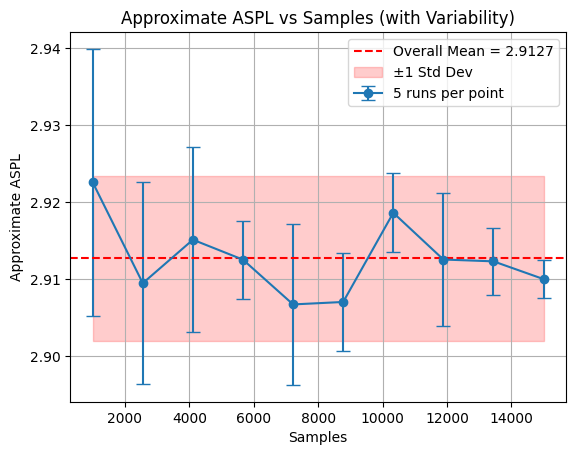

In [74]:
starting = 1000
finishing = 15000
points = 10
repeats = 5  # Number of repetitions for each sample point

samples = np.linspace(starting, finishing, points).astype(int)

# Perform multiple calculations for each sample point
y_values = np.array([[approximate_aspl(g, n) for _ in range(repeats)] for n in samples])

# Calculate mean and standard deviation for each sample point
means = y_values.mean(axis=1)
std_devs = y_values.std(axis=1)

# Calculate overall mean and standard deviation
overall_mean = y_values.mean()
overall_std = y_values.std()

print(f"Overall Mean of Approximate ASPL: {overall_mean:.4f}")
print(f"Overall Standard Deviation of Approximate ASPL: {overall_std:.4f}")

# Create the plot with error bars
plt.errorbar(samples, means, yerr=std_devs, fmt='-o', capsize=5, label=f'{repeats} runs per point')

# Display the overall mean and standard deviation on the plot
plt.axhline(y=overall_mean, color='red', linestyle='--', label=f'Overall Mean = {overall_mean:.4f}')
plt.fill_between(samples, overall_mean - overall_std, overall_mean + overall_std, color='red', alpha=0.2, label=f'±1 Std Dev')

plt.xlabel('Samples')
plt.ylabel('Approximate ASPL')
plt.title('Approximate ASPL vs Samples (with Variability)')
plt.grid(True)
plt.legend()
plt.show()

In [82]:
#Define another OG
g = nx.read_edgelist(f"orbits_d{d}_n{n}_separated_sorted/orbit_72", nodetype=int)
print("Number of nodes:",len(list(g.nodes())))
print("Number of edges",len(list(g.edges())))

Number of nodes: 16745
Number of edges 174370


In [83]:
starting = 10000 #Number of Samples Start
finishing = 15000 #Number of Samples End
points = 10 #Number of points between the range
repeats = 1  # Number of repetitions for each sample point

def statistics_approx_aspl(graph,initial_num_pairs,final_num_pair, samples_per_num_pairs, num_of_runs):
    """
    Estimate the average shortest path length (ASPL) over multiple sample sizes and runs.

    This function computes the ASPL of a given graph for varying numbers of node pairs,
    repeating the approximation multiple times for statistical robustness. It returns 
    the mean and standard deviation of the ASPL at each sample size, along with the 
    overall mean and standard deviation across all samples and runs.

    Parameters:
    -----------
    graph : networkx.Graph
        The input graph on which ASPL is to be approximated.
    initial_num_pairs : int
        The starting number of node pairs to sample.
    final_num_pair : int
        The final number of node pairs to sample.
    samples_per_num_pairs : int
        The number of different sample sizes (between initial and final) to evaluate.
    num_of_runs : int
        The number of ASPL approximations to perform per sample size.

    Returns:
    --------
    means : np.ndarray
        Mean ASPL values for each sample size.
    std_devs : np.ndarray
        Standard deviation of ASPL values for each sample size.
    overall_mean : float
        Mean ASPL across all sample sizes and runs.
    overall_std : float
        Standard deviation of ASPL across all sample sizes and runs.
    """

    samples = np.linspace(initial_num_pairs, final_num_pair, samples_per_num_pairs).astype(int)
    y_values = np.array([[approximate_aspl(graph, n) for _ in range(num_of_runs)] for n in samples])

    # Calculate mean and standard deviation for each sample point
    means = y_values.mean(axis=1)
    std_devs = y_values.std(axis=1)

    # Calculate overall mean and standard deviation
    overall_mean = y_values.mean()
    overall_std = y_values.std()
    return means, std_devs, overall_mean, overall_std






ar_mean, ar_std, tot_mean, tot_std = statistics_approx_aspl(g, starting,finishing,points,repeats)
print("Mean:",tot_mean)
print("Std:",tot_std)
print(f"Range: {tot_mean-tot_std} till {tot_mean+tot_std}")

Mean: 4.163493133948377
Std: 0.009700522794225168
Range: 4.153792611154151 till 4.173193656742602


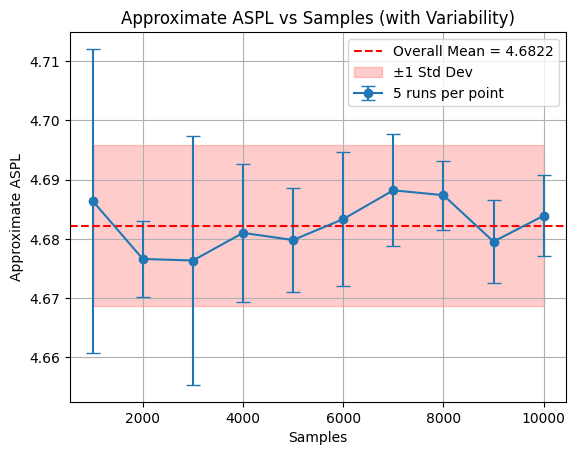

In [63]:
def plot_aspl_results(starting, finishing, points, repeats, means, std_devs, overall_mean, overall_std):
    """
    Plot the Approximate ASPL with error bars, overall mean, and variability.

    Parameters:
    - starting: Starting sample size.
    - finishing: Finishing sample size.
    - points: Number of sample points.
    - repeats: Number of repetitions per sample point.
    - means: Mean ASPL values for each sample point.
    - std_devs: Standard deviation for each sample point.
    - overall_mean: Overall mean ASPL across all samples and repetitions.
    - overall_std: Overall standard deviation ASPL across all samples and repetitions.
    """
    samples = np.linspace(starting, finishing, points).astype(int)

    # Create the plot with error bars
    plt.errorbar(samples, means, yerr=std_devs, fmt='-o', capsize=5, label=f'{repeats} runs per point')

    # Display the overall mean and standard deviation on the plot
    plt.axhline(y=overall_mean, color='red', linestyle='--', label=f'Overall Mean = {overall_mean:.4f}')
    plt.fill_between(samples, overall_mean - overall_std, overall_mean + overall_std, color='red', alpha=0.2, label=f'±1 Std Dev')

    plt.xlabel('Samples')
    plt.ylabel('Approximate ASPL')
    plt.title('Approximate ASPL vs Samples (with Variability)')
    plt.grid(True)
    plt.legend()
    plt.show()

# Usage example
plot_aspl_results(starting, finishing, points, repeats, ar_mean, ar_std, tot_mean, tot_std)

If one wants to calculate the average shortest path length for a graph the distance matrix must be defined. Then the average of all the elements belonging to the upper triangle must be calculated. Recall that the distance matrix is by definition symmetric. The problem is that obtaining this matrix is a computationally heavy task. However, in some cases, we can calculate it without the need for approximations. Then we have to compare the results from the accurate procedure and the ones we obtain from the approximation. If the residual plot is close to zero our approximation is trustworthy for predicting large graphs for which the exact method requires more time. We are going to perform two comparisons. The first one is to calculate the residuals for n = 6. The second one is to include the n = 7 but demands that OG input is less than 10 MB.

In [68]:
d = 3
n = 6

starting = 1000 #Number of Samples Start
finishing = 15000 #Number of Samples End
points = 10 #Number of points between the range
repeats = 5  # Number of repetitions for each sample point

exact_aspl = []
heut_aspl = []

for cnt in range(3,n+1):
    files_for_given_orbit = os.listdir(f"orbits_d{d}_n{cnt}_separated_sorted")
    files_for_given_orbit.sort(key=lambda x: int(x.split('_')[-1]))  # Sort the list based on the orbit number
    for file in files_for_given_orbit:
        print(f"Starting orbits_d{d}_n{cnt}_separated_sorted/{file}")
        g = nx.read_edgelist(f"orbits_d{d}_n{cnt}_separated_sorted/{file}", nodetype=int)
        temp_ex_aspl = avg_of_distance_matrix(g)
        exact_aspl.append(temp_ex_aspl)
        _, _, tot_mean, tot_std = statistics_approx_aspl(g, starting,finishing,points,repeats)
        heut_aspl.append(tot_mean)

Starting orbits_d3_n3_separated/orbit_0
Starting orbits_d3_n4_separated/orbit_0
Starting orbits_d3_n4_separated/orbit_1
Starting orbits_d3_n4_separated/orbit_2
Starting orbits_d3_n5_separated/orbit_0
Starting orbits_d3_n5_separated/orbit_1
Starting orbits_d3_n5_separated/orbit_2
Starting orbits_d3_n5_separated/orbit_3
Starting orbits_d3_n5_separated/orbit_4
Starting orbits_d3_n6_separated/orbit_0
Starting orbits_d3_n6_separated/orbit_1
Starting orbits_d3_n6_separated/orbit_2
Starting orbits_d3_n6_separated/orbit_3
Starting orbits_d3_n6_separated/orbit_4
Starting orbits_d3_n6_separated/orbit_5
Starting orbits_d3_n6_separated/orbit_6
Starting orbits_d3_n6_separated/orbit_7
Starting orbits_d3_n6_separated/orbit_8
Starting orbits_d3_n6_separated/orbit_9
Starting orbits_d3_n6_separated/orbit_10
Starting orbits_d3_n6_separated/orbit_11
Starting orbits_d3_n6_separated/orbit_12
Starting orbits_d3_n6_separated/orbit_13
Starting orbits_d3_n6_separated/orbit_14
Starting orbits_d3_n6_separated/orb

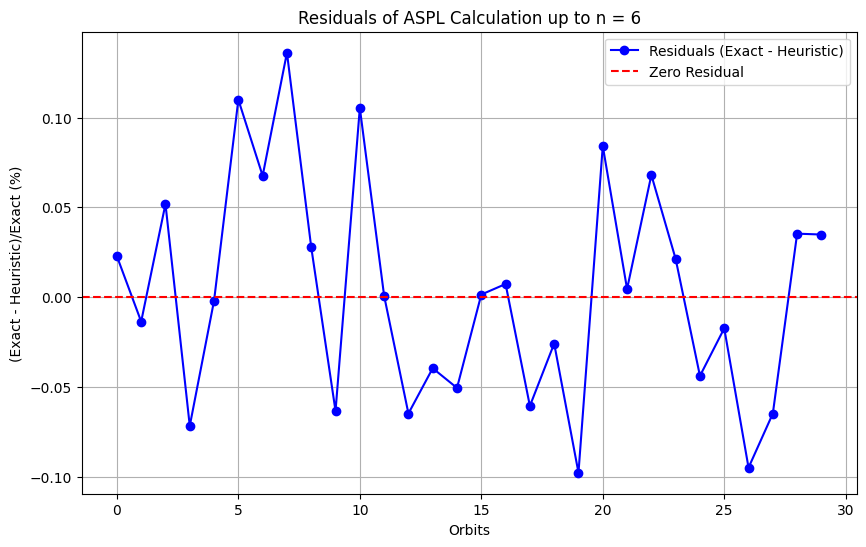

In [69]:
# Calculate residuals (Exact - Heuristic)/Exact times 100
residuals = (np.array(exact_aspl) - np.array(heut_aspl))*100/np.array(exact_aspl)

# Plot the residuals
plt.figure(figsize=(10, 6))
plt.plot(residuals, 'o-', label='Residuals (Exact - Heuristic)', color='blue')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Orbits')
plt.ylabel('(Exact - Heuristic)/Exact (%)')
plt.title('Residuals of ASPL Calculation up to n = 6')
plt.legend()
plt.grid(True)
plt.show()

Residuals for all data less than 10 MB. The exact calculation is done in ```real_join_data.py```.

In [21]:
d = 3 
for cnt in range(3,6+1):
    files_for_given_orbit = os.listdir(f"orbits_d{d}_n{cnt}_separated_sorted")
    files_for_given_orbit.sort(key=lambda x: int(x.split('_')[-1]))  # Sort the list based on the orbit number

print(files_for_given_orbit)

['orbit_0', 'orbit_1', 'orbit_2', 'orbit_3', 'orbit_4', 'orbit_5', 'orbit_6', 'orbit_7', 'orbit_8', 'orbit_9', 'orbit_10', 'orbit_11', 'orbit_12', 'orbit_13', 'orbit_14', 'orbit_15', 'orbit_16', 'orbit_17', 'orbit_18', 'orbit_19', 'orbit_20']


In [52]:
with open("og_data_final/join_og_mean_path_length.txt", "r") as f:
    exact_aspl_7_up_to_10_mb = eval(f.read())

In [85]:
d = 3
n = 7

starting = 1000 #Number of Samples Start
finishing = 10000 #Number of Samples End
points = 10 #Number of points between the range
repeats = 2  # Number of repetitions for each sample point

heut_aspl = []

for cnt in range(3,n+1):
    files_for_given_orbit = os.listdir(f"orbits_d{d}_n{cnt}_separated_sorted")
    files_for_given_orbit.sort(key=lambda x: int(x.split('_')[-1]))  # Sort the list based on the orbit number
    for file in files_for_given_orbit:
        print(f"Starting orbits_d{d}_n{cnt}_separated_sorted/{file}")
        g = nx.read_edgelist(f"orbits_d{d}_n{cnt}_separated_sorted/{file}", nodetype=int)
        _, _, tot_mean, tot_std = statistics_approx_aspl(g, starting,finishing,points,repeats)
        heut_aspl.append(tot_mean)


Starting orbits_d3_n3_separated_sorted/orbit_0
Starting orbits_d3_n4_separated_sorted/orbit_0
Starting orbits_d3_n4_separated_sorted/orbit_1
Starting orbits_d3_n4_separated_sorted/orbit_2
Starting orbits_d3_n5_separated_sorted/orbit_0
Starting orbits_d3_n5_separated_sorted/orbit_1
Starting orbits_d3_n5_separated_sorted/orbit_2
Starting orbits_d3_n5_separated_sorted/orbit_3
Starting orbits_d3_n5_separated_sorted/orbit_4
Starting orbits_d3_n6_separated_sorted/orbit_0
Starting orbits_d3_n6_separated_sorted/orbit_1
Starting orbits_d3_n6_separated_sorted/orbit_2
Starting orbits_d3_n6_separated_sorted/orbit_3
Starting orbits_d3_n6_separated_sorted/orbit_4
Starting orbits_d3_n6_separated_sorted/orbit_5
Starting orbits_d3_n6_separated_sorted/orbit_6
Starting orbits_d3_n6_separated_sorted/orbit_7
Starting orbits_d3_n6_separated_sorted/orbit_8
Starting orbits_d3_n6_separated_sorted/orbit_9
Starting orbits_d3_n6_separated_sorted/orbit_10
Starting orbits_d3_n6_separated_sorted/orbit_11
Starting or

In [91]:
create_file = False

if create_file:
    with open('og_data_final/heut_aspl_large_run.txt', 'w') as f:
        f.write(str(heut_aspl))

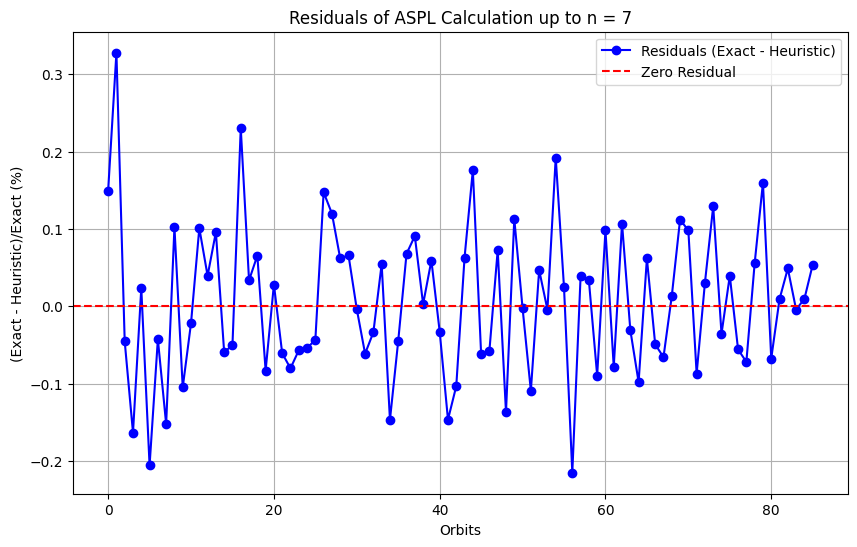

In [92]:
# Assuming exact_aspl_7_up_to_10_mb and heut_aspl are already defined as lists or arrays
exact_aspl_7_up_to_10_mb = np.array(exact_aspl_7_up_to_10_mb)
heut_aspl = np.array(heut_aspl)

# Create a mask to exclude cases where exact_aspl_7_up_to_10_mb is 0
mask = exact_aspl_7_up_to_10_mb != 0

# Calculate residuals
residuals = (exact_aspl_7_up_to_10_mb[mask] - heut_aspl[mask]) * 100 / exact_aspl_7_up_to_10_mb[mask]

if create_file:
    with open('og_data_final/residuals_aspl_large_run.txt', 'w') as f:
        f.write(str(residuals))


# Plot the residuals
plt.figure(figsize=(10, 6))
plt.plot(residuals, 'o-', label='Residuals (Exact - Heuristic)', color='blue')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual')
plt.xlabel('Orbits')
plt.ylabel('(Exact - Heuristic)/Exact (%)')
plt.title('Residuals of ASPL Calculation up to n = 7')
plt.legend()
plt.grid(True)

# Save the figure as a PNG image
plt.savefig('og_figures/aspl_residuals.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Save the residual with avg, std and error bars.

Mean of Residuals: 0.0063%
Standard Deviation of Residuals: 0.0973%


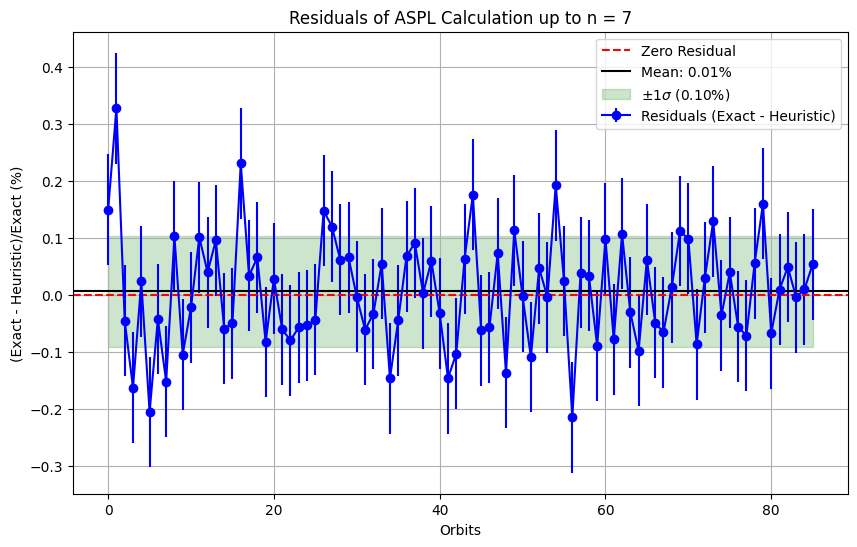

In [93]:
# Save residuals to a file if needed
if create_file:
    with open('og_data_final/residuals_aspl_large_run.txt', 'w') as f:
        f.write(str(residuals))

# Calculate statistics for the residuals
mean_residuals = np.mean(residuals)
std_residuals = np.std(residuals)

print(f"Mean of Residuals: {mean_residuals:.4f}%")
print(f"Standard Deviation of Residuals: {std_residuals:.4f}%")

# Plot the residuals with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(np.arange(len(residuals)), residuals, yerr=std_residuals, fmt='o-', label='Residuals (Exact - Heuristic)', color='blue')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual')

# Add mean and error range
plt.axhline(y=mean_residuals, color='black', linestyle='-', label=f'Mean: {mean_residuals:.2f}%')
plt.fill_between(np.arange(len(residuals)), mean_residuals - std_residuals, mean_residuals + std_residuals, color='green', alpha=0.2, label=f'±1$\sigma$ ({std_residuals:.2f}%)')

# Labels and title
plt.xlabel('Orbits')
plt.ylabel('(Exact - Heuristic)/Exact (%)')
plt.title('Residuals of ASPL Calculation up to n = 7')
plt.legend()
plt.grid(True)

# Save the figure as a PNG image
plt.savefig('og_figures/aspl_residuals_with_error_bars.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Add the probabilistic results only for the masked data and get the final data points ASLP.

[1.33333333 1.55555556 2.17567568 1.26666667 1.58181818 2.54911181
 3.01025166 2.66327343 2.527995   1.81318681 2.75592204 2.46293706
 3.51724808 3.27659961 3.85149781 2.7866728  2.83667515 4.16069069
 4.16911585 2.60806952 2.89889225 2.83667515 3.49682579 3.34367847
 3.41641726 3.14524604 3.50964686 2.21435693 2.84264398 3.18111617
 1.86666667 2.85938171 2.90272953 3.65733492 3.36087558 3.40210883
 3.7124093  4.41883948 4.45729831 3.70544764 4.72413981 3.390157
 3.39352253 4.29427693 4.14668082 4.68382189 4.15044893 4.68491577
 5.33826796 5.00895402 4.78201835 2.8198024  3.41169443 3.39352253
 4.02952263 3.60509445 4.07053369 4.11659215 3.5183461  4.15044893
 4.68491577 4.75058797 4.96075973 4.27860737 4.77945036 5.32888815
 4.90377016 5.32629147 2.91001794 4.09520136 3.66498961 3.73628953
 5.08425766 4.43178918 4.70388409 3.93509733 4.69867268 4.95932315
 4.38059268 5.33069526 5.88947627 3.12854784 4.07910328 4.98856937
 4.41840499 4.0808451  4.98659905 5.49955361 5.51824393 4.108960

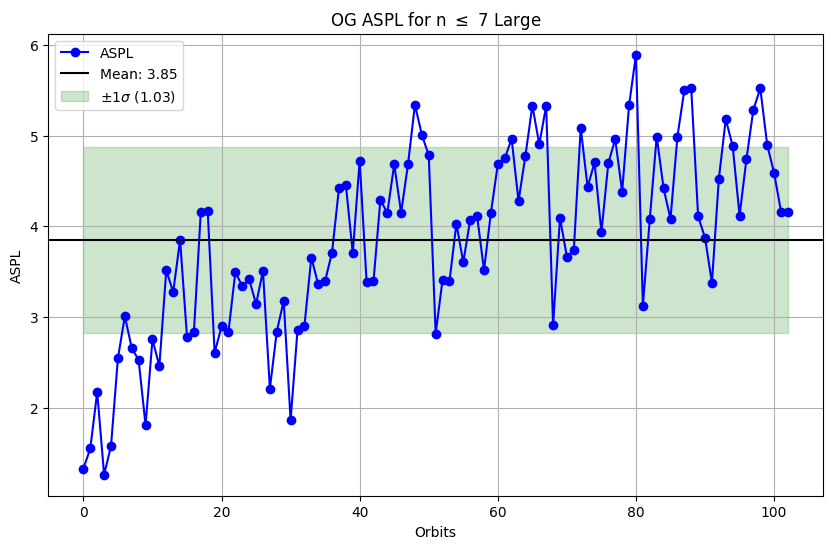

In [94]:
# Create a new array where zeros in exact_aspl_7_up_to_10_mb are replaced by heut_aspl
corrected_aspl = np.where(exact_aspl_7_up_to_10_mb == 0, heut_aspl, exact_aspl_7_up_to_10_mb)
print(corrected_aspl)

# # Save the corrected array to a file
# with open('og_data/join_final_aspl_large_run.txt', 'w') as f:
#     f.write(str(corrected_aspl))

# Save the corrected array
np.savetxt('og_data_final/join_final_aspl_large_run.txt', corrected_aspl)

# Calculate mean and standard deviation of corrected_aspl
mean_aspl = np.mean(corrected_aspl)
std_aspl = np.std(corrected_aspl)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(corrected_aspl, 'o-', label='ASPL', color='blue')

# Add mean line and ±1σ range
plt.axhline(y=mean_aspl, color='black', linestyle='-', label=f'Mean: {mean_aspl:.2f}')
plt.fill_between(np.arange(len(corrected_aspl)), mean_aspl - std_aspl, mean_aspl + std_aspl,
                 color='green', alpha=0.2, label=f'±1$\sigma$ ({std_aspl:.2f})')

# Labels and title
plt.xlabel('Orbits')
plt.ylabel('ASPL')
plt.title('OG ASPL for n $\leq$ 7 Large')
plt.legend()
plt.grid(True)

# Save the figure
plt.savefig('og_figures/final_og_aspl.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()